#  Flight Fare Prediction


### Problem Statement
Predict the price of a flight ticket using historical flight data. Accurate fare predictions can help travelers make better booking decisions and support travel price prediction applications.

### Problem Type
**Supervised Learning (Regression)**

### Input Features
- Airline
- Flight
- Source City
- Departure Time
- Stops
- Arrival Time
- Destination City
- Class
- Duration
- Days Left

### Target Variable
- Price

### Success Metrics
- **Primary:** RMSE
- **Secondary:** MAE, R² Score

### Constraints
- Predictions are based on historical data only.
- Real-time fare changes, promotions, and unexpected events are not considered.

### Goal
Build a regression model that predicts flight ticket prices as accurately as possible.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df=pd.read_csv('Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [54]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

Shape: (300153, 12)

Columns: ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

Dtypes:
 Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object


## EDA

In [55]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


Text(0.5, 1.0, 'Price vs days_left (expect a curve)')

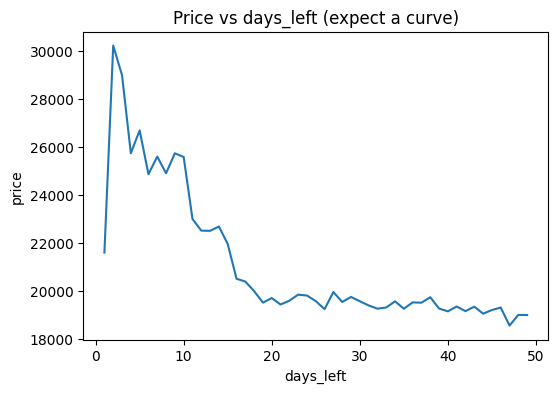

In [56]:
#price vs days_left
plt.figure(figsize=(6, 4))
sns.lineplot(data=df, x="days_left", y="price", errorbar=None)
plt.title("Price vs days_left (expect a curve)")

<Axes: xlabel='price', ylabel='Count'>

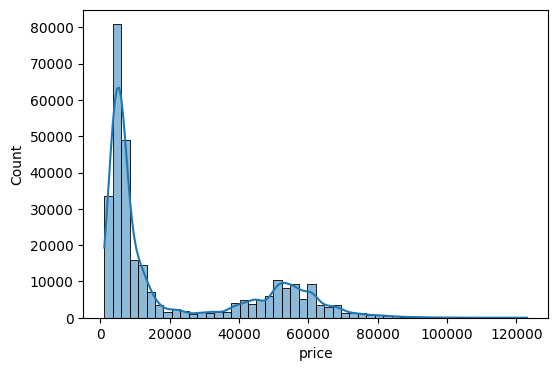

In [57]:
#price distribution
plt.figure(figsize=(6,4))
sns.histplot(df["price"],bins=50,kde=True)

Text(0.5, 1.0, 'Price vs Duration')

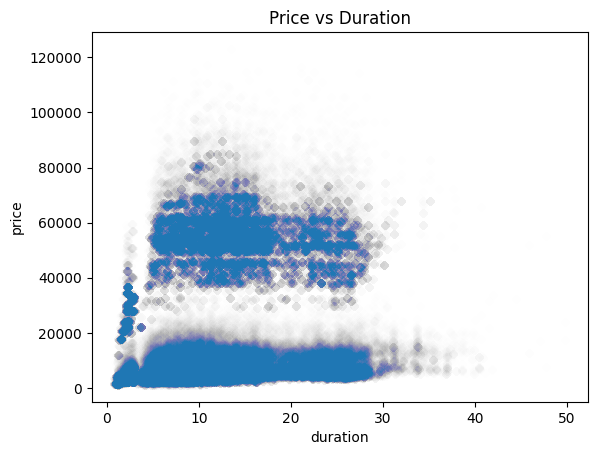

In [58]:
#price vs duration
sns.scatterplot(data=df,x="duration",y="price",alpha=0.005)
plt.title("Price vs Duration" )

In [59]:
df["duration"].corr(df["price"])

np.float64(0.20422236784542708)

<Figure size 600x400 with 0 Axes>

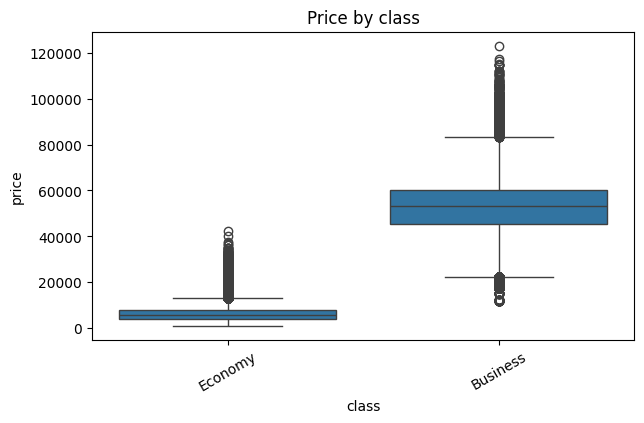

<Figure size 600x400 with 0 Axes>

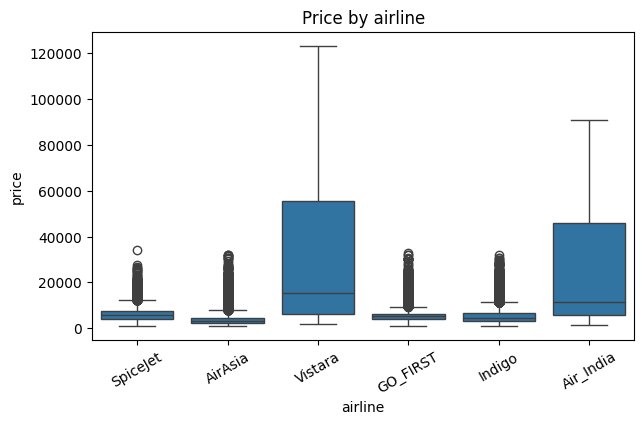

<Figure size 600x400 with 0 Axes>

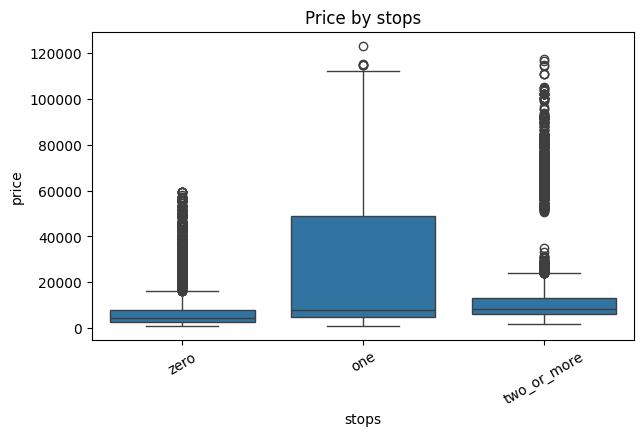

In [60]:
for col in ["class", "airline", "stops"]:
        plt.figure(figsize=(6, 4))
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=df, x=col, y="price")
        plt.title(f"Price by {col}")
        plt.xticks(rotation=30)
        plt.show()

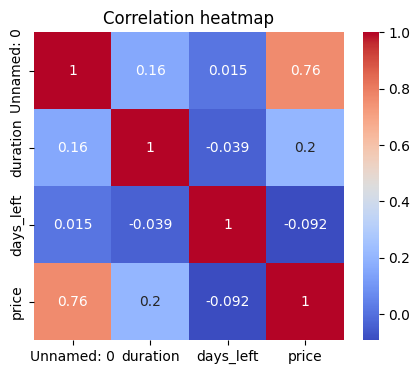

In [61]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(5, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

## DATA CLEANING

In [62]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
#droping flight name and unamed columb as no use in making predduction
drop_cols = [c for c in ["Unnamed: 0", "flight"] if c in df.columns]
df = df.drop(columns=drop_cols)

In [65]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## MOdel Training

In [66]:
Poly_feature=["days_left"]
Linear_numerical_feature=["duration"]
Categorical_feature=[ "airline", "source_city", "departure_time",
    "stops", "arrival_time", "destination_city", "class",]

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
feature_cols=Poly_feature+Linear_numerical_feature+Categorical_feature
X=df[feature_cols]
y=df["price"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
#pipeline
preprocessor=ColumnTransformer([
    ("poly",PolynomialFeatures(degree=2,include_bias=False),Poly_feature),
    ("scale",StandardScaler(),Linear_numerical_feature),
    ("encode",OneHotEncoder(handle_unknown="ignore"),Categorical_feature)
])

In [70]:
#cmpare model
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, cross_val_score

candidates={
    "Linear Regression":LinearRegression(),
    "Ridge Regression":Ridge(alpha=1.0),
    "Lasso Regression":Lasso(alpha=0.1,max_iter=1000)
}
results={}
for name,algo in candidates.items():
    pipe=Pipeline([("preprocessing",preprocessor),("model",algo)])
    score=-cross_val_score(pipe,X_train,y_train,cv=5,scoring="neg_root_mean_squared_error")
    results[name]=score.mean()
    print(f"{name}: RMSE={score.mean():.2f}")

#pick best
best_name=min(results,key=results.get)
if "Linear Regression" in results and results["Linear Regression"] <= results[best_name] + 50:
    best_name = "Linear Regression"
print(f"\nSelected model: {best_name}")
pipe = Pipeline([("preprocessing", preprocessor), ("model", candidates[best_name])])
param_grid = {"preprocessing__poly__degree": [1, 2, 3, 4]}
if best_name in ["Ridge", "Lasso"]:
    param_grid["model__alpha"] = [0.001, 0.01, 0.1, 1, 10]

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train) 
print("Best params:", grid.best_params_)
final_model = grid.best_estimator_

Linear Regression: RMSE=6663.35
Ridge Regression: RMSE=6666.88
Lasso Regression: RMSE=6663.15

Selected model: Linear Regression
Best params: {'preprocessing__poly__degree': 2}


In [71]:
y_pred=final_model.predict(X_test)
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print(f"MAE :{mae:.2f}")
print(f"RMSE :{rmse:.2f}")
print(f"R² :{r2:.2f}")

MAE :4442.47
RMSE :6673.87
R² :0.91


In [72]:
print(df["price"].mean())
print(df["price"].std())

20889.660523133203
22697.76736607447


In [73]:
import pandas as pd
error_df = pd.DataFrame({"actual": y_test, "predicted": y_pred})
error_df["abs_error"] = (error_df["actual"] - error_df["predicted"]).abs()
error_df["class"] = X_test["class"].values
print(error_df.groupby("class")["abs_error"].mean())

class
Business    8211.668402
Economy     2735.124917
Name: abs_error, dtype: float64


In [74]:
import joblib
joblib.dump(final_model, "model.pkl") 

['model.pkl']